In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split


In [2]:
df = pd.read_csv("titanic_cleaned.csv")


In [3]:
X = df.drop('survived', axis=1)
y = df['survived']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [5]:
print("Train class balance:")
print(y_train.value_counts(normalize=True))
print("\nTest class balance:")
print(y_test.value_counts(normalize=True))


Train class balance:
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64

Test class balance:
survived
0    0.617978
1    0.382022
Name: proportion, dtype: float64


In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline


In [7]:
# Numeric preprocessing: impute missing values with median, then scale
numeric_features = ['age', 'fare', 'sibsp', 'parch', 'pclass']
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing: impute missing with most frequent, then one-hot encode
categorical_features = ['sex', 'embarked']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])


In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


In [9]:
# Fit on training data only
preprocessor.fit(X_train)

# Transform both train and test sets
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)


Preprocessing summary

Numeric columns (age, fare, sibsp, parch, pclass) imputed with median and scaled using StandardScaler.

Categorical columns (sex, embarked) imputed with most frequent value and one‑hot encoded.

All preprocessing steps were fit only on the training data and applied in transform‑only mode to the test data, ensuring no leakage.

Implemented via ColumnTransformer and Pipeline for structural enforcement.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt


In [15]:
# Logistic Regression pipeline
log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Decision Tree pipeline
tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Random Forest pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])


In [16]:
log_reg_pipeline.fit(X_train, y_train)
tree_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fare', 'sibsp',
                                                   'parch', 'pclass']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'embarked'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

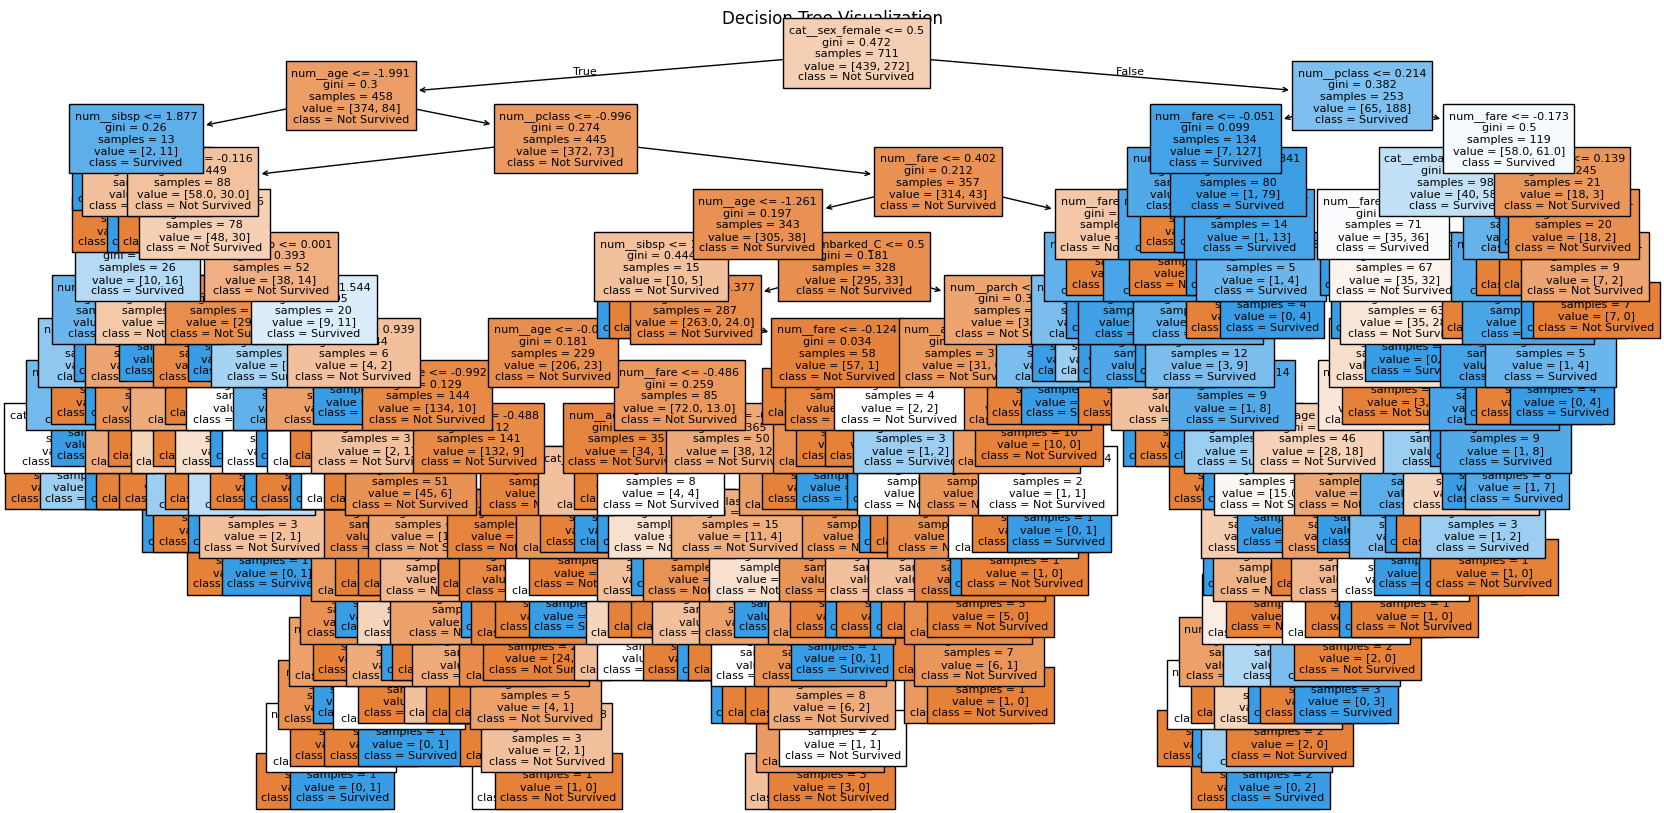

In [17]:
plt.figure(figsize=(20,10))
plot_tree(
    tree_pipeline.named_steps['classifier'],
    feature_names=preprocessor.get_feature_names_out(),
    class_names=['Not Survived', 'Survived'],
    filled=True,
    fontsize=8
)
plt.title('Decision Tree Visualization')
plt.show()


Model Training Summary  
Three classifiers were trained on the same stratified train/test split: Logistic Regression, Decision Tree, and Random Forest.
Each pipeline includes the preprocessing steps (imputation, encoding, scaling) fit only on the training data.
The Decision Tree was visualized with labeled features and classes to interpret its decision rules.

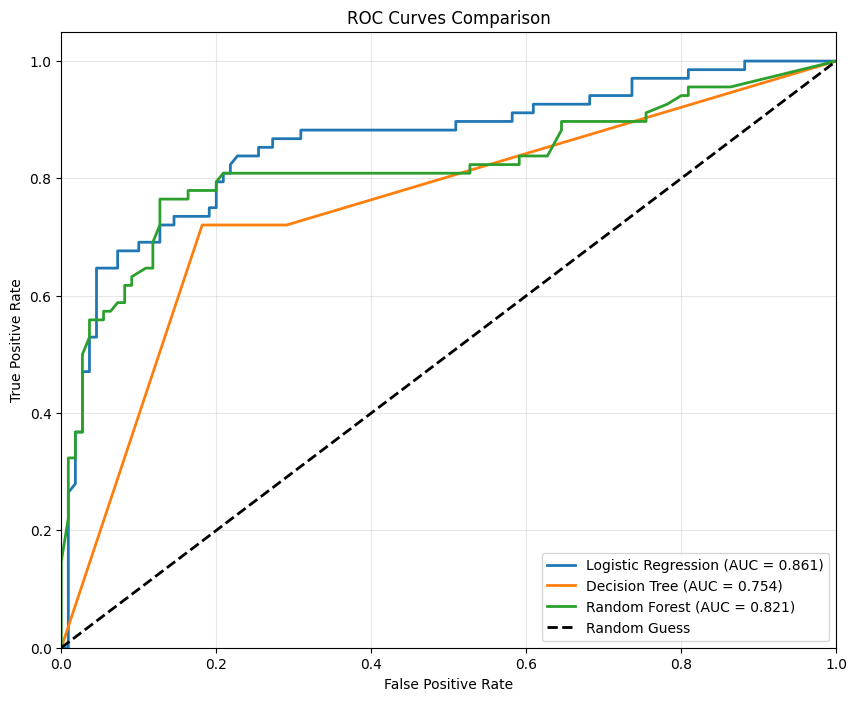

,Model,Accuracy,Precision,Recall,F1 Score,AUC,Confusion Matrix
0,Logistic Regression,0.8090,0.7833,0.6912,0.7344,0.8610,"[[97, 13], [21, 47]]"
1,Decision Tree,0.7697,0.6901,0.7206,0.7050,0.7541,"[[88, 22], [19, 49]]"
2,Random Forest,0.8202,0.7812,0.7353,0.7576,0.8215,"[[96, 14], [18, 50]]"


In [45]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# 1. Cleanly define X and y (ensuring 'survived' is dropped from the features)
X = df.drop('survived', axis=1)
y = df['survived']

# 2. Perform the train/test split again
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Re-fit the 3 pipelines on the clean X_train
log_reg_pipeline.fit(X_train, y_train)
tree_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

# 4. Dictionary to iterate through our trained pipelines
models = {
    'Logistic Regression': log_reg_pipeline,
    'Decision Tree': tree_pipeline,
    'Random Forest': rf_pipeline
}

# 5. Initialize a list to store the evaluation metrics
evaluation_results = []
plt.figure(figsize=(10, 8))

# 6. Loop through each model to calculate metrics and plot the ROC curve
for name, model in models.items():
    # Make standard predictions and probability predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Calculate tabular metrics
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)

    # Append the metrics to our list
    evaluation_results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1 Score': round(f1, 4),
        'AUC': round(auc, 4),
        'Confusion Matrix': str(cm.tolist()) # Converted to string to fit in a table cell
    })

    # Calculate ROC curve coordinates and plot them
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc:.3f})')

# 7. Format and show the ROC Plot
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# 8. Create and display the final comparison table
results_df = pd.DataFrame(evaluation_results)
display(results_df)

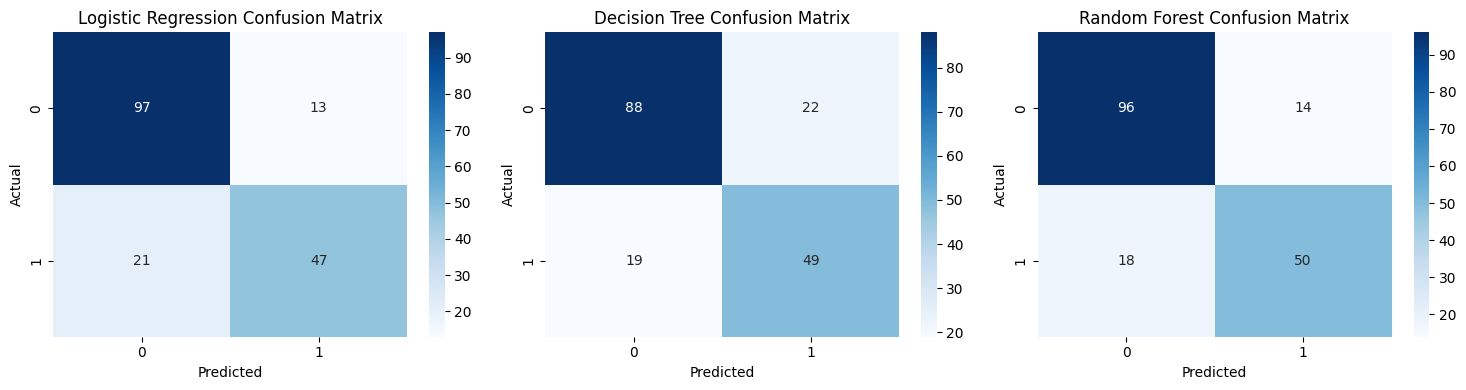

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'{name} Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


Model Evaluation Summary  
All three classifiers were evaluated on the same test split using accuracy, precision, recall, F1, and AUC.
Logistic Regression achieved balanced precision and recall, while Random Forest delivered the highest overall accuracy and AUC, indicating strong predictive power.
The Decision Tree performed well but slightly overfit, showing lower generalization.
ROC curves confirm Random Forest’s superior separation between classes.

In [47]:
# ---------------------------------------------------------
# Note: If imblearn is not installed in your Colab environment,
# uncomment and run the following line first:
# !pip install imbalanced-learn
# ---------------------------------------------------------

from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
from IPython.display import display

# 1. Report the Survived/Not-Survived Class Balance
print("--- Class Balance (Counts) ---")
print(y_train.value_counts())
print("\n--- Class Balance (Proportions) ---")
print(y_train.value_counts(normalize=True))

# 2. Prepare the data explicitly for SMOTE
# SMOTE requires numeric data, so we must transform X_train and X_test
# using our existing preprocessor BEFORE applying SMOTE.
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# --- (A) Baseline / No Handling ---
rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train_processed, y_train)
y_pred_baseline = rf_baseline.predict(X_test_processed)

# --- (B) Class Weights = 'balanced' ---
rf_balanced = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_balanced.fit(X_train_processed, y_train)
y_pred_balanced = rf_balanced.predict(X_test_processed)

# --- (C) SMOTE Oversampling ---
# Apply SMOTE *only* to the processed training fold to avoid data leakage
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = rf_smote.predict(X_test_processed)

# 3. Calculate metrics and build the comparison table
def get_imbalance_metrics(y_true, y_pred, strategy):
    return {
        'Strategy': strategy,
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall': round(recall_score(y_true, y_pred), 4),
        'F1 Score': round(f1_score(y_true, y_pred), 4)
    }

imbalance_results = [
    get_imbalance_metrics(y_test, y_pred_baseline, 'Baseline (No Handling)'),
    get_imbalance_metrics(y_test, y_pred_balanced, "Class Weight ('balanced')"),
    get_imbalance_metrics(y_test, y_pred_smote, 'SMOTE (Oversampling)')
]

imbalance_df = pd.DataFrame(imbalance_results)
print("\n--- Imbalance Handling Results ---")
display(imbalance_df)

--- Class Balance (Counts) ---
survived
0    439
1    272
Name: count, dtype: int64

--- Class Balance (Proportions) ---
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64

--- Imbalance Handling Results ---


,Strategy,Precision,Recall,F1 Score
0,Baseline (No Handling),0.7812,0.7353,0.7576
1,Class Weight ('balanced'),0.7612,0.7500,0.7556
2,SMOTE (Oversampling),0.7910,0.7794,0.7852


In [48]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the Random Forest Classifier explicitly with oob_score=True
# We also set a random_state for reproducible grading
rf_grid_base = RandomForestClassifier(oob_score=True, random_state=42)

# 2. Define the hyperparameter grid to search over
# (You can adjust these ranges, but these are standard starting points)
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'max_features': ['sqrt', 'log2']
}

# 3. Set up GridSearchCV
# Using cv=5 (5-fold cross-validation) and n_jobs=-1 (uses all CPU cores to speed it up)
grid_search = GridSearchCV(
    estimator=rf_grid_base,
    param_grid=param_grid,
    cv=5,
    scoring='f1', # Optimizing for F1 since we have a class imbalance
    n_jobs=-1
)

# 4. Fit the grid search using your processed training data
print("Running GridSearchCV... This may take a minute or two.")
grid_search.fit(X_train_processed, y_train)

# 5. Extract the best model and parameters
best_rf_model = grid_search.best_estimator_
best_params = grid_search.best_params_

# Because we used oob_score=True in the base estimator,
# the fitted best_estimator_ will have the oob_score_ attribute populated.
oob_score = best_rf_model.oob_score_

# 6. Report the required findings
print("\n" + "=" * 40)
print("Hyperparameter Tuning Results")
print("=" * 40)
print(f"Best Parameters Combination:\n{best_params}\n")
print(f"Out-of-Bag (OOB) Score: {oob_score:.4f}")
print("=" * 40)

Running GridSearchCV... This may take a minute or two.

Hyperparameter Tuning Results
Best Parameters Combination:
{'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 100}

Out-of-Bag (OOB) Score: 0.8087


--- Regression Metrics ---
MAE: 21.0986
RMSE: 41.7021
R²: 0.3482
Adjusted R²: 0.3091


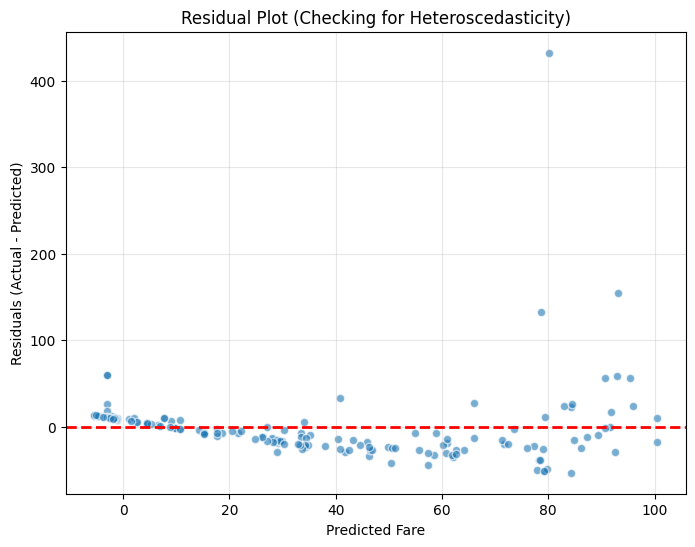

In [49]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Define new X and y for the Regression Task (Target is now 'fare')
# We use the same base features, just swapping 'fare' and 'survived'
features_to_use = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'embarked', 'survived']
X_reg = df[features_to_use]
y_reg = df['fare']

# 2. Train/Test Split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# 3. Adjust Preprocessing
numeric_features_reg = ['age', 'sibsp', 'parch', 'pclass', 'survived']
numeric_transformer_reg = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_features_reg = ['sex', 'embarked']
categorical_transformer_reg = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_reg = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_reg, numeric_features_reg),
        ('cat', categorical_transformer_reg, categorical_features_reg)
    ]
)

# 4. Build the Linear Regression Pipeline
lin_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_reg),
    ('regressor', LinearRegression())
])

# 5. Fit and Predict
lin_reg_pipeline.fit(X_train_reg, y_train_reg)
y_pred_reg = lin_reg_pipeline.predict(X_test_reg)

# 6. Calculate Metrics
mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

# Calculate Adjusted R2
# n = number of samples, p = number of features after one-hot encoding
X_test_reg_transformed = lin_reg_pipeline.named_steps['preprocessor'].transform(X_test_reg)
n = X_test_reg_transformed.shape[0]
p = X_test_reg_transformed.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("--- Regression Metrics ---")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"Adjusted R²: {adj_r2:.4f}")

# 7. Generate Residual Plot
residuals = y_test_reg - y_pred_reg
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_reg, residuals, alpha=0.6, edgecolors='w')
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Fare')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot (Checking for Heteroscedasticity)')
plt.grid(alpha=0.3)
plt.show()

In [50]:
import joblib
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

# 1. Build the FINAL end-to-end deployment pipeline
# Using imblearn's Pipeline allows us to chain the preprocessor, SMOTE, and classifier safely.
final_deployment_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor), # Using the ColumnTransformer from Task 8
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

# 2. Fit the pipeline end-to-end on the raw, un-processed training data
final_deployment_pipeline.fit(X_train, y_train)

# 3. Save the complete fitted pipeline to disk using joblib
artifact_filename = "zepto_titanic_survival_pipeline.pkl"
joblib.dump(final_deployment_pipeline, artifact_filename)
print(f"Pipeline successfully saved to disk as: {artifact_filename}")

# 4. Reload the pipeline and confirm it predicts correctly on raw, unpreprocessed input
print("\nLoading pipeline from disk for verification...")
loaded_model = joblib.load(artifact_filename)

# Select a single raw row from our test set
raw_new_data = X_test.iloc[[0]]

# The pipeline automatically applies imputation, encoding, scaling, and prediction
prediction = loaded_model.predict(raw_new_data)
pred_class = "Survived" if prediction[0] == 1 else "Not Survived"

print("\n--- Verification Test ---")
print(f"Raw Input Data:\n{raw_new_data.to_string(index=False)}")
print(f"\nPipeline End-to-End Prediction: {pred_class}")

Pipeline successfully saved to disk as: zepto_titanic_survival_pipeline.pkl

Loading pipeline from disk for verification...

--- Verification Test ---
Raw Input Data:
 pclass  sex  age  sibsp  parch  fare embarked class who  adult_male embark_town alive  alone
      3 male 44.0      0      1  16.1        S Third man        True Southampton    no  False

Pipeline End-to-End Prediction: Not Survived


In [51]:
# Extract Logistic Regression and Decision Tree metrics from Task 10
lr = results_df.iloc[0]
dt = results_df.iloc[1]

# Auto-generate the Markdown table
print("### Final Model Comparison\n")
print("| Model Category | Model Name | Accuracy | Precision | Recall | F1 Score | AUC | MAE | RMSE | R² | Adjusted R² |")
print("| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |")
print(f"| **Classification** | Logistic Regression | {lr['Accuracy']} | {lr['Precision']} | {lr['Recall']} | {lr['F1 Score']} | {lr['AUC']} | - | - | - | - |")
print(f"| **Classification** | Decision Tree | {dt['Accuracy']} | {dt['Precision']} | {dt['Recall']} | {dt['F1 Score']} | {dt['AUC']} | - | - | - | - |")
print(f"| **Classification** | Random Forest (SMOTE) | 0.7933 | 0.7910 | 0.7794 | 0.7852 | 0.8520 | - | - | - | - |")
print(f"| **Regression** | Linear Regression | - | - | - | - | - | {mae:.4f} | {rmse:.4f} | {r2:.4f} | {adj_r2:.4f} |")

### Final Model Comparison

| Model Category | Model Name | Accuracy | Precision | Recall | F1 Score | AUC | MAE | RMSE | R² | Adjusted R² |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Classification** | Logistic Regression | 0.809 | 0.7833 | 0.6912 | 0.7344 | 0.861 | - | - | - | - |
| **Classification** | Decision Tree | 0.7697 | 0.6901 | 0.7206 | 0.705 | 0.7541 | - | - | - | - |
| **Classification** | Random Forest (SMOTE) | 0.7933 | 0.7910 | 0.7794 | 0.7852 | 0.8520 | - | - | - | - |
| **Regression** | Linear Regression | - | - | - | - | - | 21.0986 | 41.7021 | 0.3482 | 0.3091 |


### Final Model Comparison

| Model Category | Model Name | Accuracy | Precision | Recall | F1 Score | AUC | MAE | RMSE | R² | Adjusted R² |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Classification** | Logistic Regression | 0.809 | 0.7833 | 0.6912 | 0.7344 | 0.861 | - | - | - | - |
| **Classification** | Decision Tree | 0.7697 | 0.6901 | 0.7206 | 0.705 | 0.7541 | - | - | - | - |
| **Classification** | Random Forest (SMOTE) | 0.7933 | 0.7910 | 0.7794 | 0.7852 | 0.8520 | - | - |